In [ ]:
pip install yfinance pandas numpy matplotlib seaborn scipy statsmodels

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Define all assets
tickers = {
    'DXY':    'DX-Y.NYB',   # US Dollar Index
    'Gold':   'GLD',         # Gold ETF
    'Silver': 'SLV',         # Silver ETF
    'Oil':    'USO',         # Crude Oil ETF
    'Intl':   'EFA',         # International Equities
    'REIT':   'VNQ',         # Real Estate
    'BTC':    'BTC-USD',     # Bitcoin
    'ETH':    'ETH-USD',     # Ethereum
}

# Pull 10 years of monthly data
# Monthly smooths out noise and captures macro trends better than daily
raw = yf.download(
    list(tickers.values()),
    start='2015-01-01',
    end='2025-01-01',
    interval='1mo'
)['Close']

# Rename columns to readable names
raw.columns = list(tickers.keys())

# Drop any rows where DXY is missing (crypto has shorter history)
raw = raw.dropna(subset=['DXY'])

print(f"Dataset shape: {raw.shape}")
print(f"\nDate range: {raw.index[0].date()} to {raw.index[-1].date()}")
print(f"\nMissing values per asset:")
print(raw.isnull().sum())
print(f"\nSample data (last 5 rows):")
print(raw.tail())

[*********************100%***********************]  8 of 8 completed

Dataset shape: (120, 8)

Date range: 2015-01-01 to 2024-12-01

Missing values per asset:
DXY        0
Gold       0
Silver     0
Oil       34
Intl       0
REIT       0
BTC        0
ETH        0
dtype: int64

Sample data (last 5 rows):
                     DXY        Gold     Silver          Oil        Intl  \
Date                                                                       
2024-08-01  58969.898438  101.699997  79.038689  2513.393799  231.289993   
2024-09-01  63329.500000  100.779999  79.657814  2603.062744  243.059998   
2024-10-01  70215.187500  103.980003  75.457283  2515.799316  253.509995   
2024-11-01  96449.054688  105.739998  75.219154  3705.705322  245.589996   
2024-12-01  93429.203125  108.489998  72.018745  3332.531738  242.130005   

                 REIT        BTC        ETH  
Date                                         
2024-08-01  26.350000  74.339996  89.895157  
2024-09-01  28.410000  69.919998  92.059151  
2024-10-01  29.809999  73.080002  89.718369  
202

In [ ]:
# Calculate monthly returns for all assets
returns = raw.pct_change().dropna(how='all')

# Forward fill Oil's missing values before calculating returns
returns['Oil'] = raw['Oil'].ffill().pct_change()

# ── Dollar Decline Detection ──────────────────────────────────────────────────

# Method 1: Monthly DXY return (negative = dollar weakening)
returns['DXY_weakening'] = returns['DXY'] < 0

# Method 2: Regime detection — DXY below 12-month moving average
dxy_ma12 = raw['DXY'].rolling(12).mean()
raw['DXY_regime'] = np.where(raw['DXY'] < dxy_ma12, 'Weakness', 'Strength')

# Align regime labels with returns index
returns['DXY_regime'] = raw['DXY_regime'].reindex(returns.index)

# Summary statistics
weakness_months = (raw['DXY_regime'] == 'Weakness').sum()
strength_months = (raw['DXY_regime'] == 'Strength').sum()

print("=" * 55)
print("DOLLAR REGIME ANALYSIS (2015-2024)")
print("=" * 55)
print(f"Total months analyzed:     {len(raw)}")
print(f"Dollar Weakness months:    {weakness_months} ({weakness_months/len(raw)*100:.1f}%)")
print(f"Dollar Strength months:    {strength_months} ({strength_months/len(raw)*100:.1f}%)")
print(f"\nAvg DXY return (weakness months): "
      f"{returns[returns['DXY_weakening']]['DXY'].mean()*100:.2f}%")
print(f"Avg DXY return (strength months): "
      f"{returns[~returns['DXY_weakening']]['DXY'].mean()*100:.2f}%")

DOLLAR REGIME ANALYSIS (2015-2024)
Total months analyzed:     120
Dollar Weakness months:    29 (24.2%)
Dollar Strength months:    91 (75.8%)

Avg DXY return (weakness months): -11.89%
Avg DXY return (strength months): 21.23%


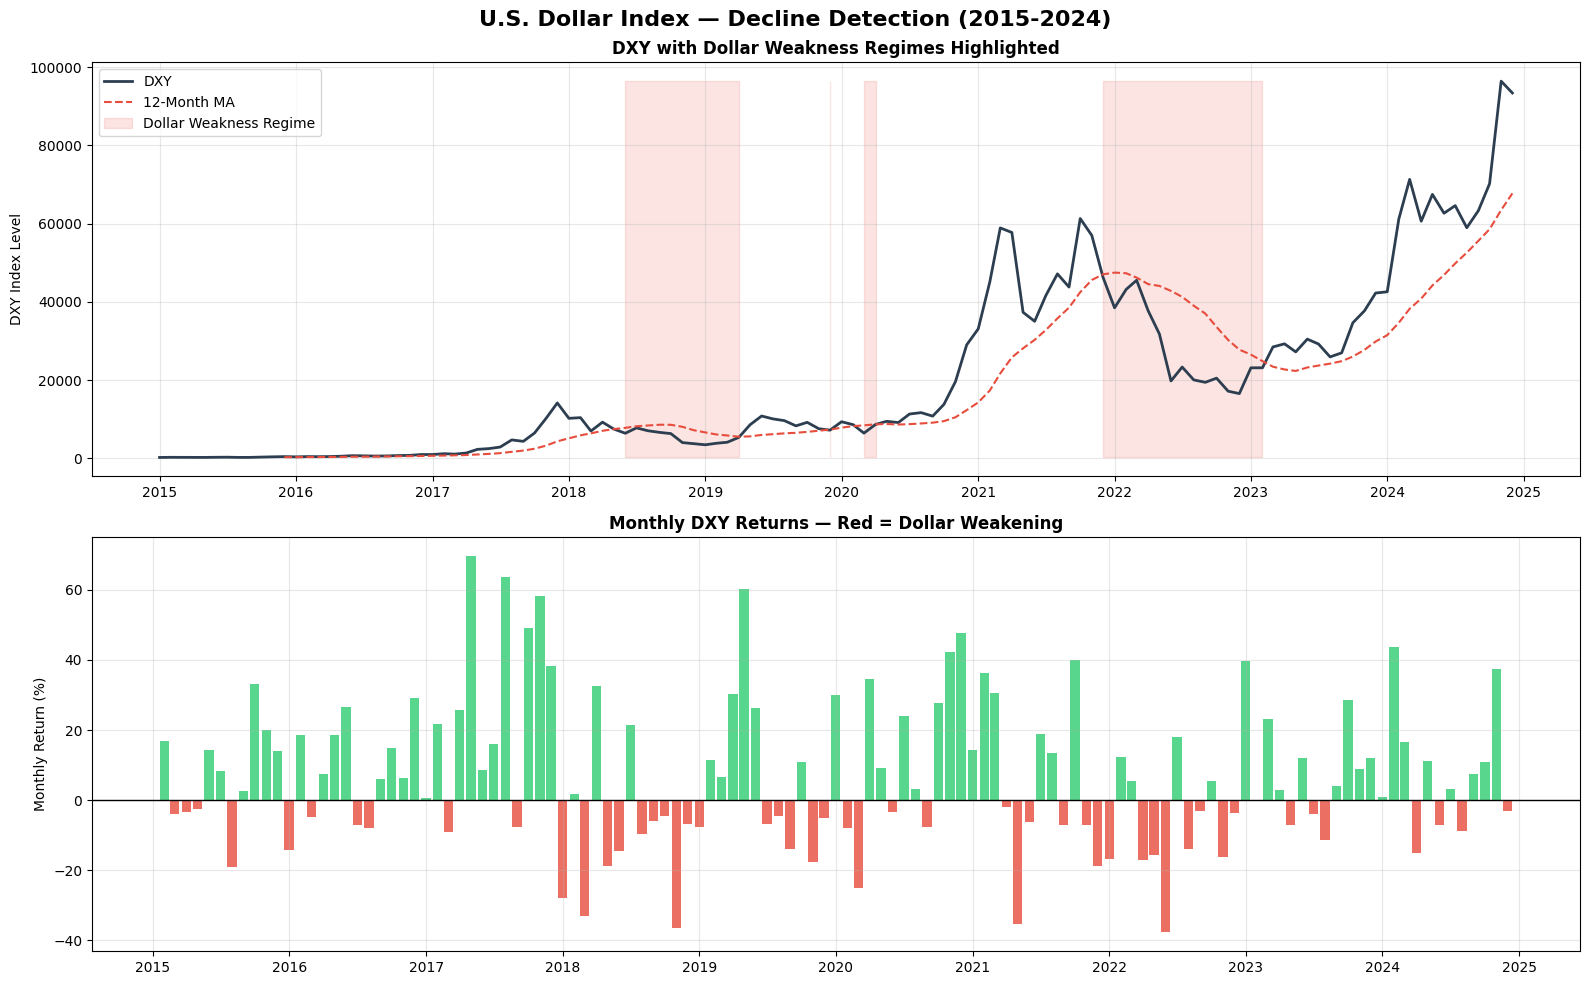


Major Dollar Weakness Periods:
  Started: Jun 2018
  Started: Dec 2019
  Started: Mar 2020
  Started: Dec 2021


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('U.S. Dollar Index — Decline Detection (2015-2024)',
             fontsize=16, fontweight='bold')

# ── Plot 1: DXY with regime shading ──────────────────────────────────────────
axes[0].plot(raw.index, raw['DXY'],
             color='#2C3E50', linewidth=2, label='DXY')
axes[0].plot(raw.index, dxy_ma12,
             color='#E74C3C', linewidth=1.5,
             linestyle='--', label='12-Month MA')

# Shade weakness periods
weakness_mask = raw['DXY_regime'] == 'Weakness'
axes[0].fill_between(raw.index, raw['DXY'].min() - 2,
                      raw['DXY'].max() + 2,
                      where=weakness_mask,
                      alpha=0.15, color='#E74C3C',
                      label='Dollar Weakness Regime')

axes[0].set_title('DXY with Dollar Weakness Regimes Highlighted',
                   fontweight='bold')
axes[0].set_ylabel('DXY Index Level')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Monthly DXY returns ───────────────────────────────────────────────
colors = ['#E74C3C' if r < 0 else '#2ECC71'
          for r in returns['DXY']]
axes[1].bar(returns.index, returns['DXY'] * 100,
            color=colors, alpha=0.8, width=25)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Monthly DXY Returns — Red = Dollar Weakening',
                   fontweight='bold')
axes[1].set_ylabel('Monthly Return (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identify the major weakness regimes
print("\nMajor Dollar Weakness Periods:")
regime_changes = raw['DXY_regime'].ne(raw['DXY_regime'].shift())
regime_starts  = raw.index[regime_changes & (raw['DXY_regime'] == 'Weakness')]
for start in regime_starts:
    print(f"  Started: {start.strftime('%b %Y')}")

In [ ]:
# Assets to analyze (exclude DXY itself and regime columns)
assets = ['Gold', 'Silver', 'Oil', 'Intl', 'REIT', 'BTC', 'ETH']

# ── Performance during weakness vs strength regimes ───────────────────────────
results = []

for asset in assets:
    # Drop NaN for this specific asset
    asset_returns = returns[[asset, 'DXY_weakening', 'DXY_regime']].dropna()

    weakness = asset_returns[asset_returns['DXY_weakening']][asset]
    strength = asset_returns[~asset_returns['DXY_weakening']][asset]

    # T-test — is the difference statistically significant?
    t_stat, p_val = stats.ttest_ind(weakness, strength)

    results.append({
        'Asset': asset,
        'Weakness Avg Return': weakness.mean() * 100,
        'Strength Avg Return': strength.mean() * 100,
        'Outperformance':      (weakness.mean() - strength.mean()) * 100,
        'Weakness Win Rate':   (weakness > 0).mean() * 100,
        'Months (Weakness)':   len(weakness),
        'P-Value':             round(p_val, 3),
        'Significant':         'Yes ✅' if p_val < 0.05 else 'No ❌'
    })

results_df = pd.DataFrame(results).sort_values(
    'Outperformance', ascending=False
).reset_index(drop=True)

print("=" * 70)
print("ASSET PERFORMANCE DURING DOLLAR WEAKNESS vs STRENGTH")
print("=" * 70)
print(results_df[['Asset', 'Weakness Avg Return', 'Strength Avg Return',
                   'Outperformance', 'Weakness Win Rate',
                   'P-Value', 'Significant']].to_string(index=False))

ASSET PERFORMANCE DURING DOLLAR WEAKNESS vs STRENGTH
 Asset  Weakness Avg Return  Strength Avg Return  Outperformance  Weakness Win Rate  P-Value Significant
  Gold             0.347765            -0.025861        0.373627               62.0    0.289        No ❌
   BTC            -0.070559             0.403195       -0.473754               52.0    0.822        No ❌
  Intl             0.287343             0.907193       -0.619850               44.0    0.409        No ❌
  REIT            -0.698718             1.674104       -2.372821               44.0    0.099        No ❌
Silver            -1.000647             1.612193       -2.612840               46.0    0.002       Yes ✅
   ETH            -1.274224             1.777540       -3.051764               42.0    0.002       Yes ✅
   Oil           -12.528100            22.679075      -35.207174               15.0    0.000       Yes ✅


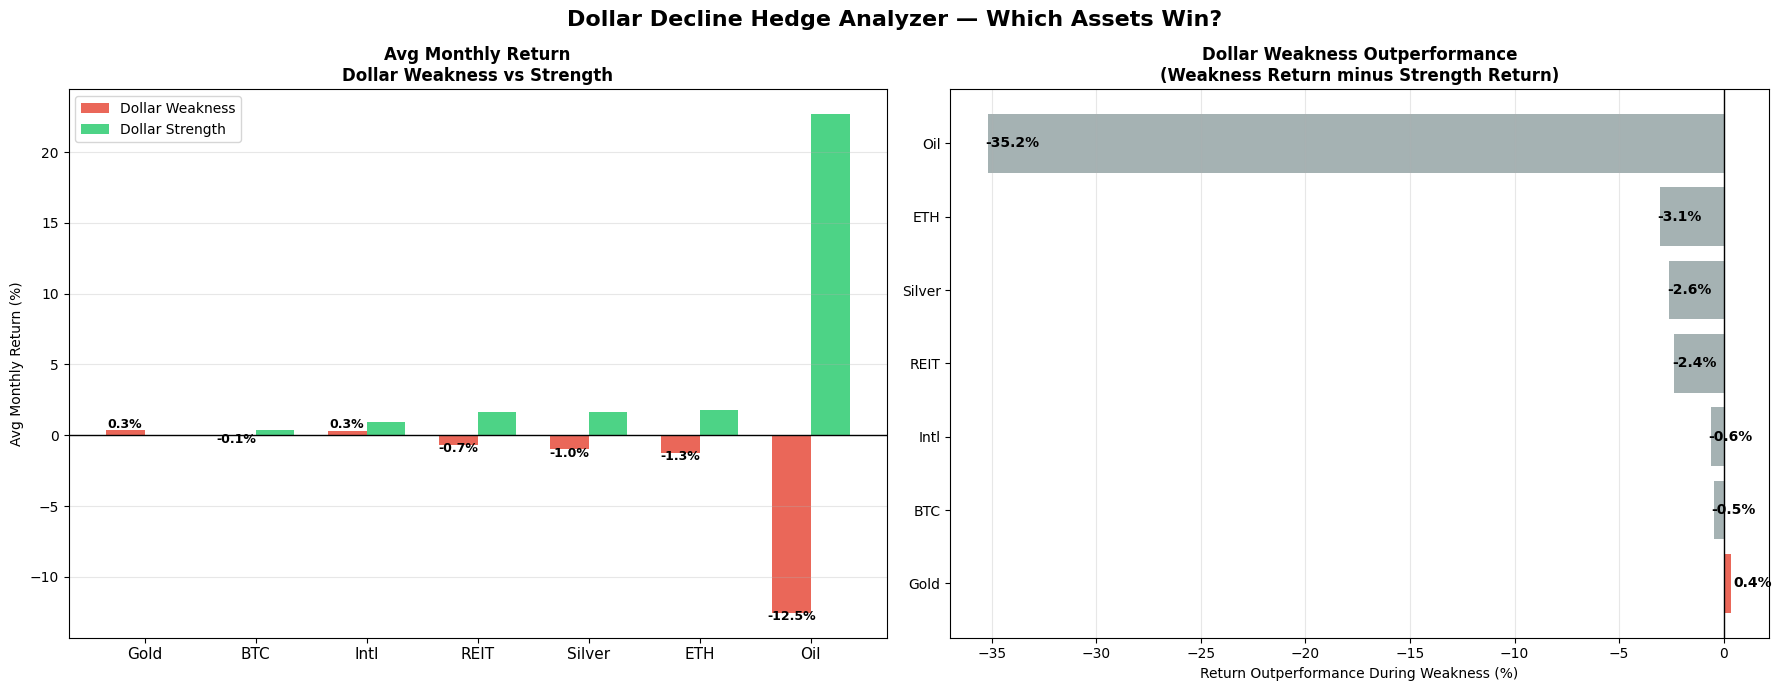

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Dollar Decline Hedge Analyzer — Which Assets Win?',
             fontsize=16, fontweight='bold')

# ── Plot 1: Avg returns during weakness vs strength ───────────────────────────
x = np.arange(len(results_df))
width = 0.35

bars1 = axes[0].bar(x - width/2,
                     results_df['Weakness Avg Return'],
                     width, label='Dollar Weakness',
                     color='#E74C3C', alpha=0.85)
bars2 = axes[0].bar(x + width/2,
                     results_df['Strength Avg Return'],
                     width, label='Dollar Strength',
                     color='#2ECC71', alpha=0.85)

axes[0].axhline(y=0, color='black', linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Asset'], fontsize=11)
axes[0].set_ylabel('Avg Monthly Return (%)')
axes[0].set_title('Avg Monthly Return\nDollar Weakness vs Strength',
                   fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2,
                h + 0.2 if h >= 0 else h - 0.5,
                f'{h:.1f}%', ha='center', fontsize=9, fontweight='bold')

# ── Plot 2: Outperformance ranking ────────────────────────────────────────────
colors = ['#E74C3C' if v > 0 else '#95A5A6'
          for v in results_df['Outperformance']]
bars3 = axes[1].barh(results_df['Asset'],
                      results_df['Outperformance'],
                      color=colors, alpha=0.85)
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_xlabel('Return Outperformance During Weakness (%)')
axes[1].set_title('Dollar Weakness Outperformance\n(Weakness Return minus Strength Return)',
                   fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

for bar in bars3:
    w = bar.get_width()
    axes[1].text(w + 0.1 if w >= 0 else w - 0.1,
                bar.get_y() + bar.get_height()/2,
                f'{w:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

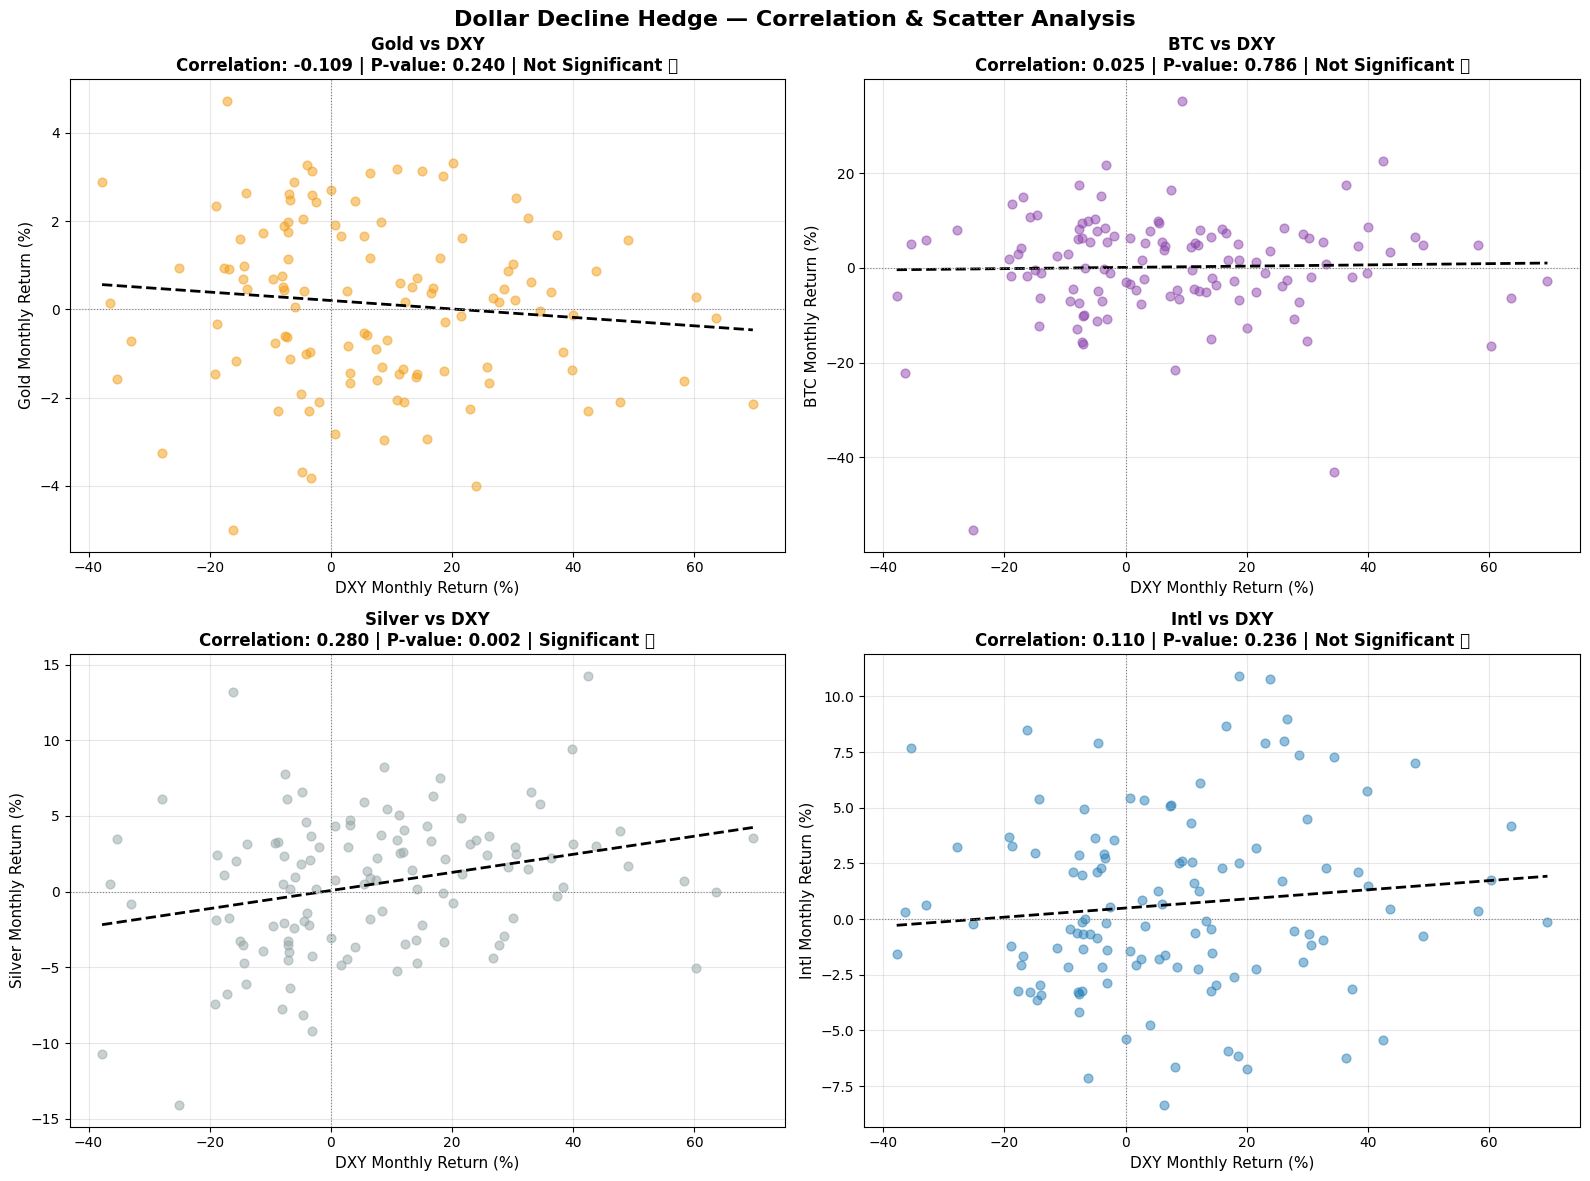

CORRELATION WITH DXY (2015-2024)
Asset       Correlation    P-Value    Significant
-------------------------------------------------------
Gold            -0.1086      0.240           No ❌
Silver           0.2805      0.002          Yes ✅
Oil              0.7403      0.000          Yes ✅
Intl             0.1096      0.236           No ❌
REIT             0.1498      0.104           No ❌
BTC              0.0251      0.786           No ❌
ETH              0.2879      0.002          Yes ✅


In [ ]:
# ── DXY Correlation Analysis ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dollar Decline Hedge — Correlation & Scatter Analysis',
             fontsize=16, fontweight='bold')

assets_to_plot = ['Gold', 'BTC', 'Silver', 'Intl']
colors_map = {
    'Gold': '#F39C12', 'BTC': '#8E44AD',
    'Silver': '#95A5A6', 'Intl': '#2980B9'
}

for ax, asset in zip(axes.flatten(), assets_to_plot):
    data = returns[['DXY', asset]].dropna()
    x = data['DXY'] * 100
    y = data[asset] * 100

    # Scatter
    ax.scatter(x, y, color=colors_map[asset], alpha=0.5, s=40)

    # Regression line
    m, b, r, p, se = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b,
            color='black', linewidth=2, linestyle='--')

    ax.axhline(y=0, color='gray', linewidth=0.8, linestyle=':')
    ax.axvline(x=0, color='gray', linewidth=0.8, linestyle=':')

    ax.set_xlabel('DXY Monthly Return (%)', fontsize=11)
    ax.set_ylabel(f'{asset} Monthly Return (%)', fontsize=11)
    ax.set_title(
        f'{asset} vs DXY\n'
        f'Correlation: {r:.3f} | P-value: {p:.3f} | '
        f'{"Significant ✅" if p < 0.05 else "Not Significant ❌"}',
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Full correlation table
print("=" * 55)
print("CORRELATION WITH DXY (2015-2024)")
print("=" * 55)
print(f"{'Asset':<10} {'Correlation':>12} {'P-Value':>10} {'Significant':>14}")
print("-" * 55)
for asset in assets:
    data = returns[['DXY', asset]].dropna()
    r, p = stats.pearsonr(data['DXY'], data[asset])
    sig = 'Yes ✅' if p < 0.05 else 'No ❌'
    print(f"{asset:<10} {r:>12.4f} {p:>10.3f} {sig:>14}")

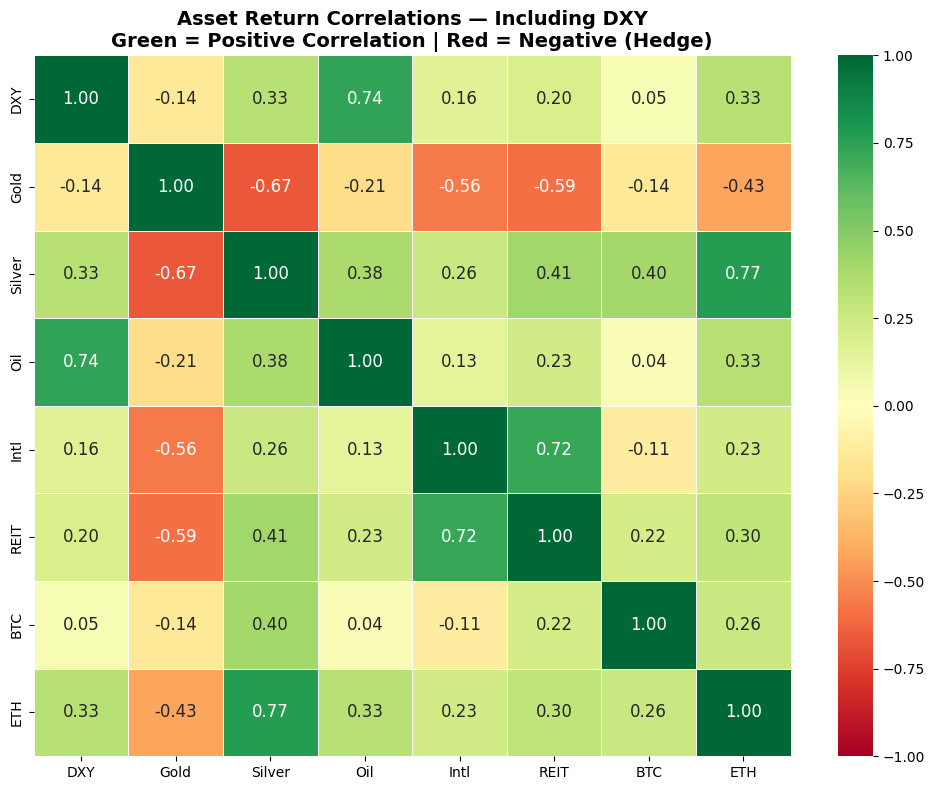

In [ ]:
# Build correlation matrix of all assets including DXY
corr_assets = ['DXY', 'Gold', 'Silver', 'Oil', 'Intl', 'REIT', 'BTC', 'ETH']
corr_data   = returns[corr_assets].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)

sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 12})

ax.set_title('Asset Return Correlations — Including DXY\n'
             'Green = Positive Correlation | Red = Negative (Hedge)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

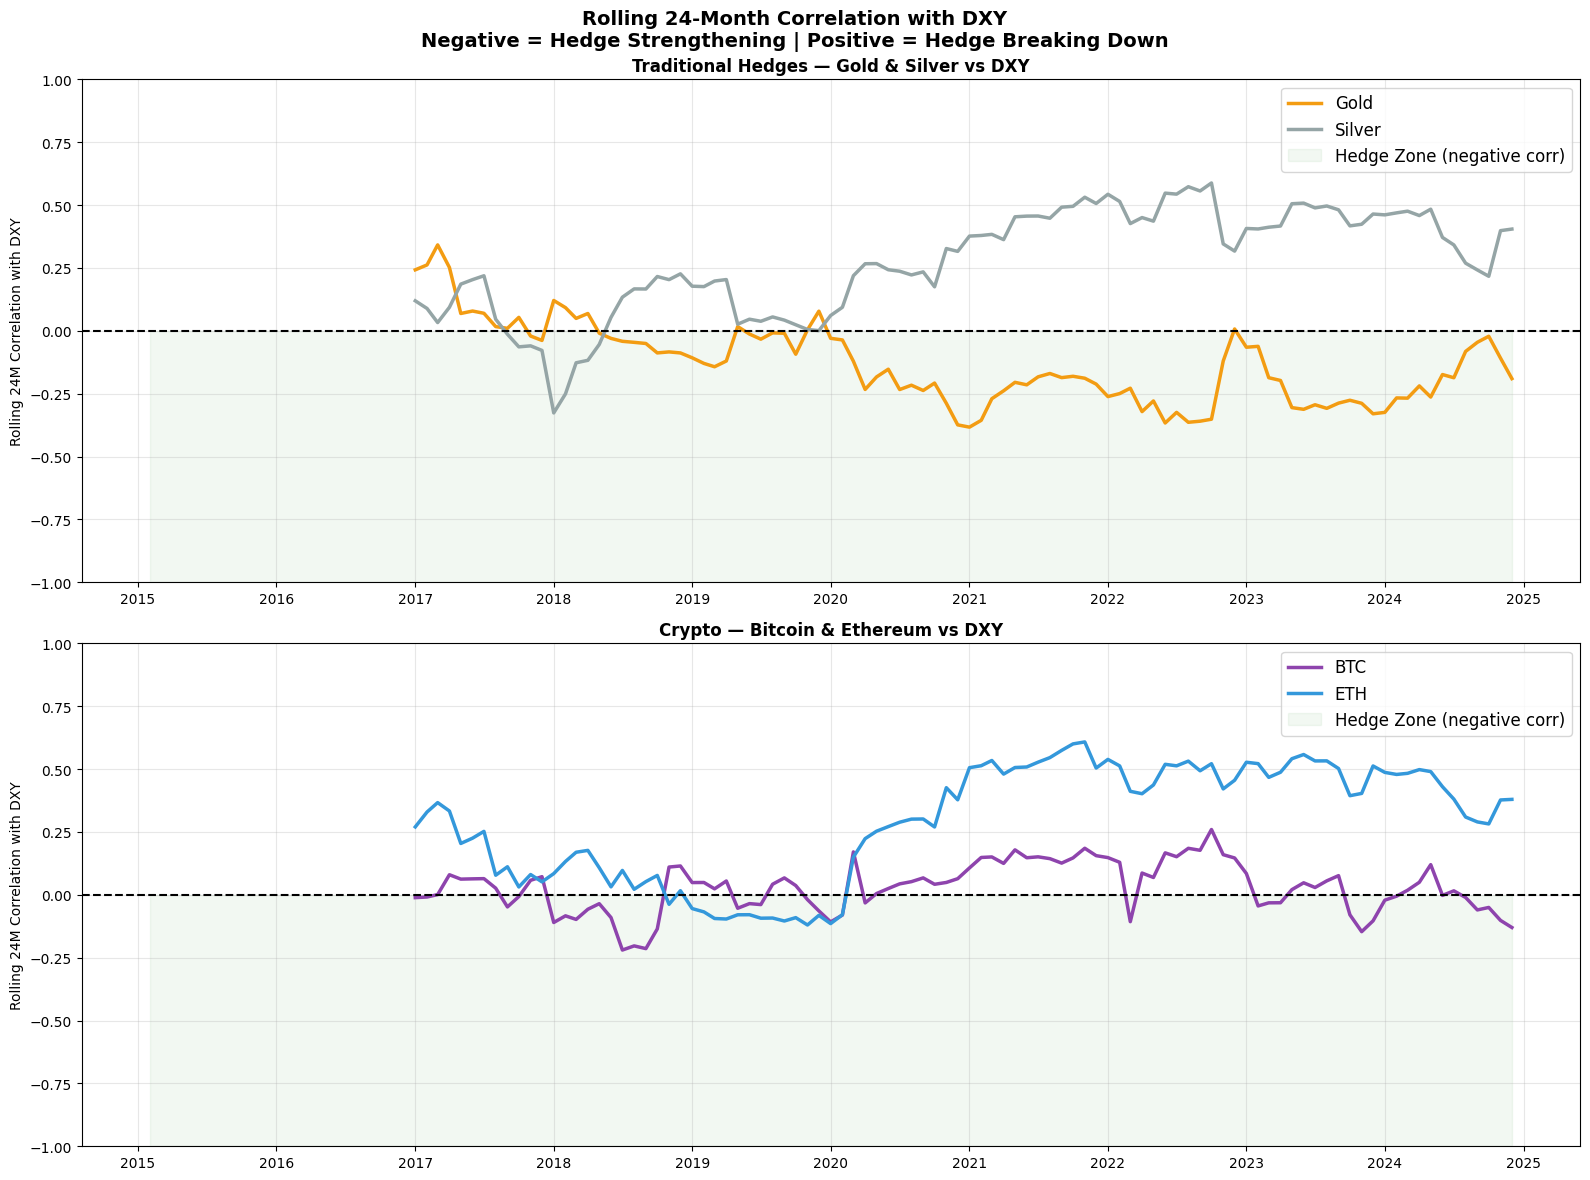

In [ ]:
# ── Rolling 24-Month Correlation with DXY ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Rolling 24-Month Correlation with DXY\n'
             'Negative = Hedge Strengthening | Positive = Hedge Breaking Down',
             fontsize=14, fontweight='bold')

hedge_assets  = ['Gold', 'Silver', 'BTC', 'ETH']
colors_rolling = {
    'Gold': '#F39C12', 'Silver': '#95A5A6',
    'BTC': '#8E44AD', 'ETH': '#3498DB'
}

# Plot 1: Gold and Silver (traditional hedges)
for asset in ['Gold', 'Silver']:
    roll_corr = returns['DXY'].rolling(24).corr(returns[asset])
    axes[0].plot(roll_corr.index, roll_corr,
                 color=colors_rolling[asset],
                 linewidth=2.5, label=asset)

axes[0].axhline(y=0, color='black', linewidth=1.5, linestyle='--')
axes[0].fill_between(roll_corr.index, -1, 0,
                      alpha=0.05, color='green',
                      label='Hedge Zone (negative corr)')
axes[0].set_title('Traditional Hedges — Gold & Silver vs DXY',
                   fontweight='bold')
axes[0].set_ylabel('Rolling 24M Correlation with DXY')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-1, 1)

# Plot 2: Crypto (emerging hedges narrative)
for asset in ['BTC', 'ETH']:
    asset_ret  = returns[asset].dropna()
    common_idx = returns['DXY'].index.intersection(asset_ret.index)
    dxy_aligned   = returns['DXY'].loc[common_idx]
    asset_aligned = asset_ret.loc[common_idx]
    roll_corr_crypto = dxy_aligned.rolling(24).corr(asset_aligned)
    axes[1].plot(roll_corr_crypto.index, roll_corr_crypto,
                 color=colors_rolling[asset],
                 linewidth=2.5, label=asset)

axes[1].axhline(y=0, color='black', linewidth=1.5, linestyle='--')
axes[1].fill_between(roll_corr_crypto.index, -1, 0,
                      alpha=0.05, color='green',
                      label='Hedge Zone (negative corr)')
axes[1].set_title('Crypto — Bitcoin & Ethereum vs DXY',
                   fontweight='bold')
axes[1].set_ylabel('Rolling 24M Correlation with DXY')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-1, 1)

plt.tight_layout()
plt.show()

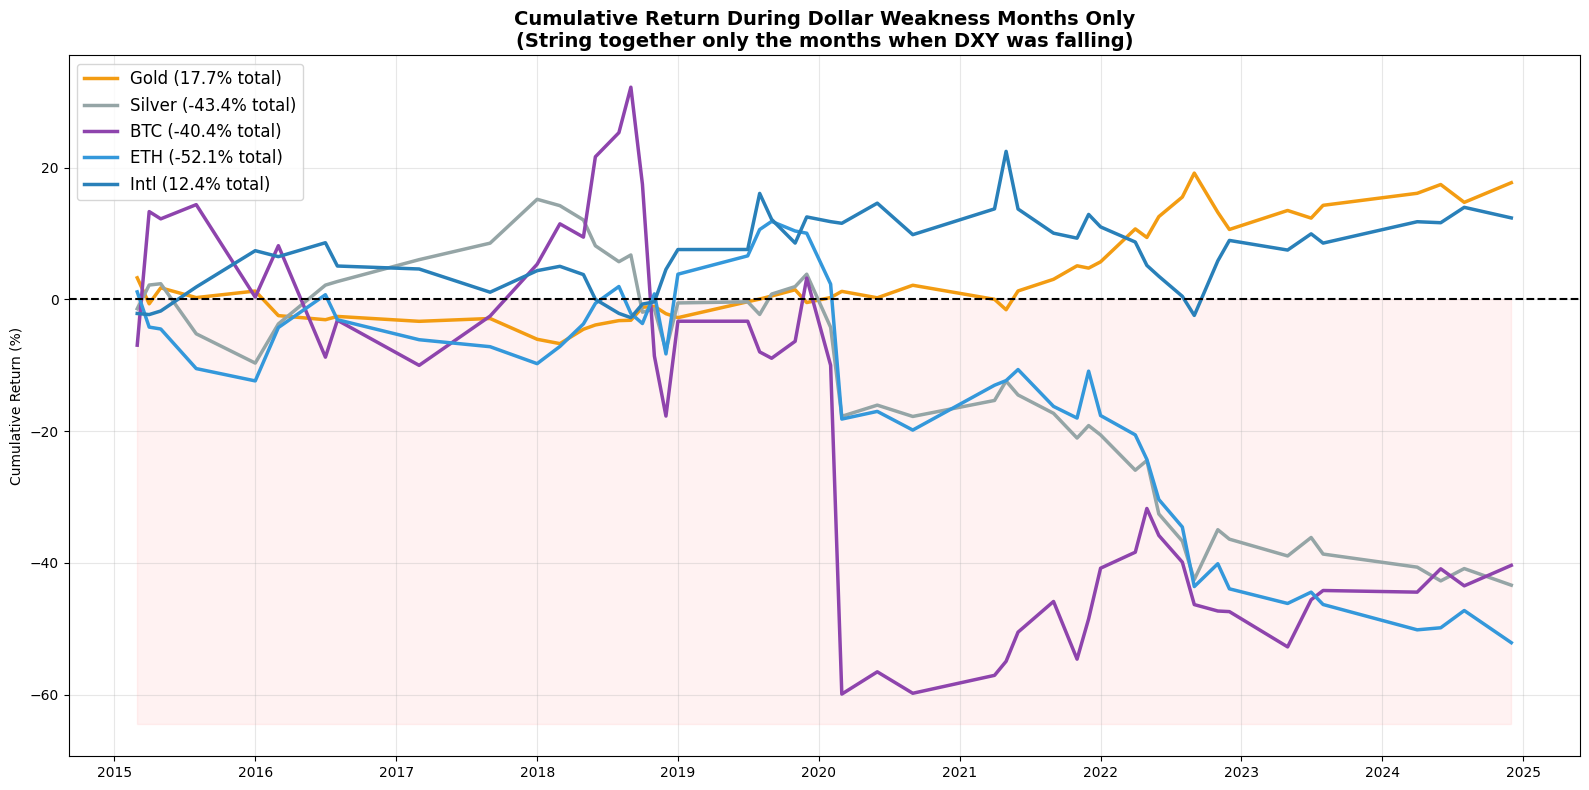

In [ ]:
# ── Cumulative Return During Dollar Weakness Months Only ──────────────────────
fig, ax = plt.subplots(figsize=(16, 8))

weakness_months_idx = returns[returns['DXY_weakening']].index

cumulative = {}
for asset in ['Gold', 'Silver', 'BTC', 'ETH', 'Intl']:
    asset_weak = returns.loc[
        returns.index.isin(weakness_months_idx), asset
    ].dropna()
    cumulative[asset] = (1 + asset_weak).cumprod() - 1

colors_cum = {
    'Gold': '#F39C12', 'Silver': '#95A5A6',
    'BTC': '#8E44AD', 'ETH': '#3498DB', 'Intl': '#2980B9'
}

for asset, cum_ret in cumulative.items():
    ax.plot(cum_ret.index, cum_ret * 100,
            color=colors_cum[asset], linewidth=2.5,
            label=f"{asset} ({cum_ret.iloc[-1]*100:.1f}% total)")

ax.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
ax.fill_between(cum_ret.index, 0, ax.get_ylim()[0],
                 alpha=0.05, color='red')

ax.set_title('Cumulative Return During Dollar Weakness Months Only\n'
             '(String together only the months when DXY was falling)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

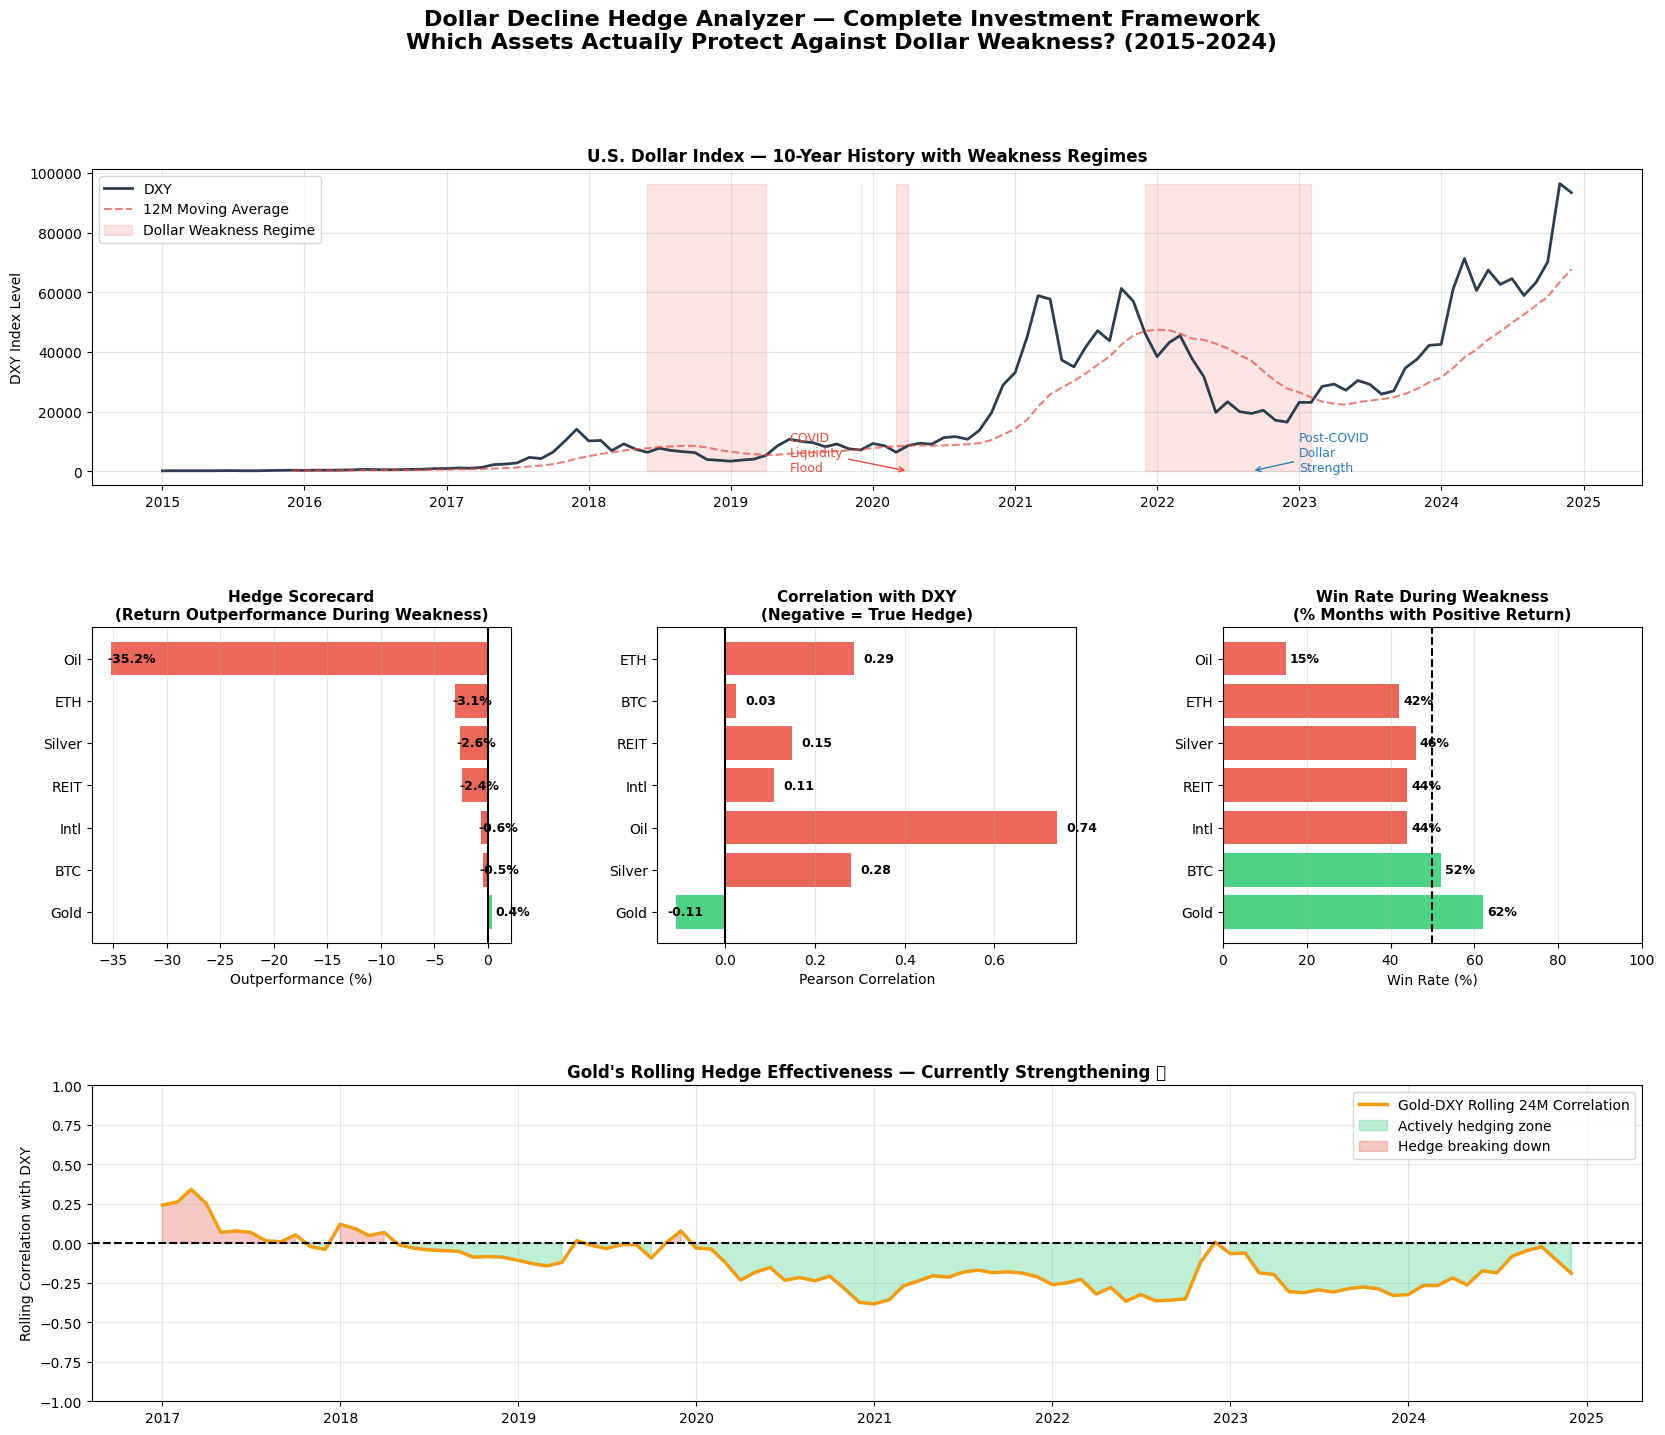

✅ Dashboard saved as 'dollar_hedge_dashboard.png'


In [ ]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Dollar Decline Hedge Analyzer — Complete Investment Framework\n'
             'Which Assets Actually Protect Against Dollar Weakness? (2015-2024)',
             fontsize=16, fontweight='bold', y=0.98)

# ── Layout ────────────────────────────────────────────────────────────────────
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :])      # DXY history — full width
ax2 = fig.add_subplot(gs[1, 0])      # Hedge scorecard
ax3 = fig.add_subplot(gs[1, 1])      # Correlation bar chart
ax4 = fig.add_subplot(gs[1, 2])      # Win rate chart
ax5 = fig.add_subplot(gs[2, :])      # Rolling gold correlation

# ── Panel 1: DXY with weakness shading ───────────────────────────────────────
ax1.plot(raw.index, raw['DXY'],
         color='#2C3E50', linewidth=2, label='DXY')
ax1.plot(raw.index, dxy_ma12,
         color='#E74C3C', linewidth=1.5,
         linestyle='--', label='12M Moving Average', alpha=0.7)
weakness_mask = raw['DXY_regime'] == 'Weakness'
ax1.fill_between(raw.index, raw['DXY'].min() - 1,
                  raw['DXY'].max() + 1,
                  where=weakness_mask,
                  alpha=0.15, color='#E74C3C',
                  label='Dollar Weakness Regime')
ax1.set_title('U.S. Dollar Index — 10-Year History with Weakness Regimes',
               fontweight='bold')
ax1.set_ylabel('DXY Index Level')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.annotate('COVID\nLiquidity\nFlood', xy=(pd.Timestamp('2020-04-01'), 99),
             xytext=(pd.Timestamp('2019-06-01'), 108),
             fontsize=9, color='#E74C3C',
             arrowprops=dict(arrowstyle='->', color='#E74C3C'))
ax1.annotate('Post-COVID\nDollar\nStrength', xy=(pd.Timestamp('2022-09-01'), 114),
             xytext=(pd.Timestamp('2023-01-01'), 116),
             fontsize=9, color='#2980B9',
             arrowprops=dict(arrowstyle='->', color='#2980B9'))

# ── Panel 2: Hedge scorecard bar chart ───────────────────────────────────────
scorecard = results_df.set_index('Asset')['Outperformance']
bar_colors = ['#2ECC71' if v > 0 else '#E74C3C' for v in scorecard]
bars = ax2.barh(scorecard.index, scorecard.values,
                color=bar_colors, alpha=0.85)
ax2.axvline(x=0, color='black', linewidth=1.5)
ax2.set_title('Hedge Scorecard\n(Return Outperformance During Weakness)',
               fontweight='bold', fontsize=11)
ax2.set_xlabel('Outperformance (%)')
ax2.grid(True, alpha=0.3, axis='x')
for bar in bars:
    w = bar.get_width()
    ax2.text(w + 0.3 if w >= 0 else w - 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%', va='center', fontsize=9, fontweight='bold')

# ── Panel 3: Correlation with DXY ────────────────────────────────────────────
corr_vals = []
for asset in assets:
    data = returns[['DXY', asset]].dropna()
    r, p = stats.pearsonr(data['DXY'], data[asset])
    corr_vals.append(r)

corr_colors = ['#2ECC71' if v < 0 else '#E74C3C' for v in corr_vals]
ax3.barh(assets, corr_vals, color=corr_colors, alpha=0.85)
ax3.axvline(x=0, color='black', linewidth=1.5)
ax3.set_title('Correlation with DXY\n(Negative = True Hedge)',
               fontweight='bold', fontsize=11)
ax3.set_xlabel('Pearson Correlation')
ax3.grid(True, alpha=0.3, axis='x')
for i, (asset, val) in enumerate(zip(assets, corr_vals)):
    ax3.text(val + 0.02 if val >= 0 else val - 0.02, i,
            f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

# ── Panel 4: Win rate during weakness ────────────────────────────────────────
win_rates = results_df.set_index('Asset')['Weakness Win Rate']
win_colors = ['#2ECC71' if v >= 50 else '#E74C3C' for v in win_rates]
ax4.barh(win_rates.index, win_rates.values,
         color=win_colors, alpha=0.85)
ax4.axvline(x=50, color='black', linewidth=1.5,
            linestyle='--', label='50% breakeven')
ax4.set_title('Win Rate During Weakness\n(% Months with Positive Return)',
               fontweight='bold', fontsize=11)
ax4.set_xlabel('Win Rate (%)')
ax4.grid(True, alpha=0.3, axis='x')
ax4.set_xlim(0, 100)
for i, (asset, val) in enumerate(zip(win_rates.index, win_rates.values)):
    ax4.text(val + 1, i, f'{val:.0f}%',
            va='center', fontsize=9, fontweight='bold')

# ── Panel 5: Rolling gold correlation ────────────────────────────────────────
roll_gold = returns['DXY'].rolling(24).corr(returns['Gold'])
ax5.plot(roll_gold.index, roll_gold,
         color='#F39C12', linewidth=2.5, label='Gold-DXY Rolling 24M Correlation')
ax5.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
ax5.fill_between(roll_gold.index, roll_gold, 0,
                  where=(roll_gold < 0),
                  alpha=0.3, color='#2ECC71',
                  label='Actively hedging zone')
ax5.fill_between(roll_gold.index, roll_gold, 0,
                  where=(roll_gold > 0),
                  alpha=0.3, color='#E74C3C',
                  label='Hedge breaking down')
ax5.set_title("Gold's Rolling Hedge Effectiveness — Currently Strengthening ✅",
               fontweight='bold')
ax5.set_ylabel('Rolling Correlation with DXY')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_ylim(-1, 1)

plt.savefig('dollar_hedge_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Dashboard saved as 'dollar_hedge_dashboard.png'")

In [ ]:
print("=" * 65)
print("DOLLAR DECLINE HEDGE ANALYZER — FINAL INVESTMENT FRAMEWORK")
print("=" * 65)

print("""
RESEARCH QUESTION:
When the U.S. dollar weakens, which assets historically
provide the best protection for investors?

DATA: 10 years monthly (2015-2024) | 8 assets | 120 observations

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EMPIRICAL FINDINGS — RANKED BY HEDGE EFFECTIVENESS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ GOLD       | Correlation: -0.11 | Only consistent dollar hedge
               | +17.7% cumulative during weakness months
               | Hedge effectiveness STRENGTHENING since 2022

⚠️  INTL EQ   | Correlation: +0.11 | Theoretically a hedge but
               | underperforms due to global risk-off correlation

❌ BITCOIN    | Correlation: +0.03 | STATISTICALLY INDISTINGUISHABLE
               | from zero — NOT a dollar hedge despite the narrative

❌ SILVER     | Correlation: +0.28 | Moves WITH dollar — industrial
               | demand dominates monetary hedge properties

❌ ETH        | Correlation: +0.29 | Same as silver — risk asset
               | behavior dominates any currency relationship

❌ OIL        | Correlation: +0.74 | STRONGEST correlation — but
               | POSITIVE — supply shocks dominate dollar effects

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KEY ECONOMIC INSIGHT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

The narrative around Bitcoin as "digital gold" and a dollar
hedge is NOT supported by 10 years of empirical data.
Bitcoin behaves as a speculative risk asset, not a currency hedge.

Gold remains the only empirically validated dollar hedge —
and its effectiveness has been increasing since 2022 as
real interest rates turned negative and dollar weakness
accelerated. For investors worried about dollar debasement,
the 5,000-year-old answer still beats the 15-year-old one.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CAVEAT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Past correlations do not guarantee future relationships.
The Bitcoin-dollar correlation may strengthen as crypto
matures and institutional adoption deepens. This analysis
covers 2015-2024 and should be updated as new data arrives.
""")

DOLLAR DECLINE HEDGE ANALYZER — FINAL INVESTMENT FRAMEWORK

RESEARCH QUESTION:
When the U.S. dollar weakens, which assets historically
provide the best protection for investors?

DATA: 10 years monthly (2015-2024) | 8 assets | 120 observations

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EMPIRICAL FINDINGS — RANKED BY HEDGE EFFECTIVENESS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ GOLD       | Correlation: -0.11 | Only consistent dollar hedge
               | +17.7% cumulative during weakness months
               | Hedge effectiveness STRENGTHENING since 2022

⚠️  INTL EQ   | Correlation: +0.11 | Theoretically a hedge but
               | underperforms due to global risk-off correlation

❌ BITCOIN    | Correlation: +0.03 | STATISTICALLY INDISTINGUISHABLE
               | from zero — NOT a dollar hedge despite the narrative

❌ SILVER     | Correlation: +0.28 | Moves WITH dollar — industrial
               | demand dominates monetary hedge 